# Plot network using R method (switch to cytoscape later)

In [1]:
suppressMessages(library(igraph))
suppressMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(destiny))
suppressMessages(library(GGally))
suppressMessages(library(igraph))
suppressMessages(library(network))
suppressMessages(library(sna))
# suppressMessages(library(intergraph))
suppressMessages(library(ggraph))
suppressMessages(library(tibble))
suppressMessages(library(tidygraph))
suppressMessages(library(data.table))
suppressMessages(library(ggpubr))

Warning message:
“package ‘destiny’ was built under R version 4.1.3”
Warning message:
“package ‘network’ was built under R version 4.1.3”
Warning message:
“package ‘sna’ was built under R version 4.1.3”
Warning message:
“package ‘statnet.common’ was built under R version 4.1.3”
Warning message:
“package ‘tidygraph’ was built under R version 4.1.3”


In [123]:
# Load default settings
here::i_am("rna/trajectories/infer_trajectory.R")
source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [2]:
io = list()
io$basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna_atac/gene_regulatory_networks/scenicplus/blood/scenicplus/'
io$GRN = file.path(io$basedir, 'eRegulon_metadata_filtered.csv')
io$TFs_to_keep = file.path(io$basedir, 'eRegulon_to_keep.csv')

theme_graph <- function() {
  theme_classic() +
    theme(
      axis.line = element_blank(), 
      axis.text = element_blank(),
      axis.ticks = element_blank(), 
      axis.title = element_blank(),
      legend.position = "none"
    )
}

In [3]:
GRN = fread(io$GRN)
TFs_to_keep = fread(io$TFs_to_keep, header=T) %>% setnames('Gene_signature_name')

In [4]:
nrow(GRN)
GRN_filt = GRN[Gene_signature_name %in% TFs_to_keep$Gene_signature_name] %>% .[Gene %in% TF]
nrow(GRN_filt)

[1] 152173

[1] 3883

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



$`1`

$`2`

attr(,"class")
[1] "list"      "ggarrange"

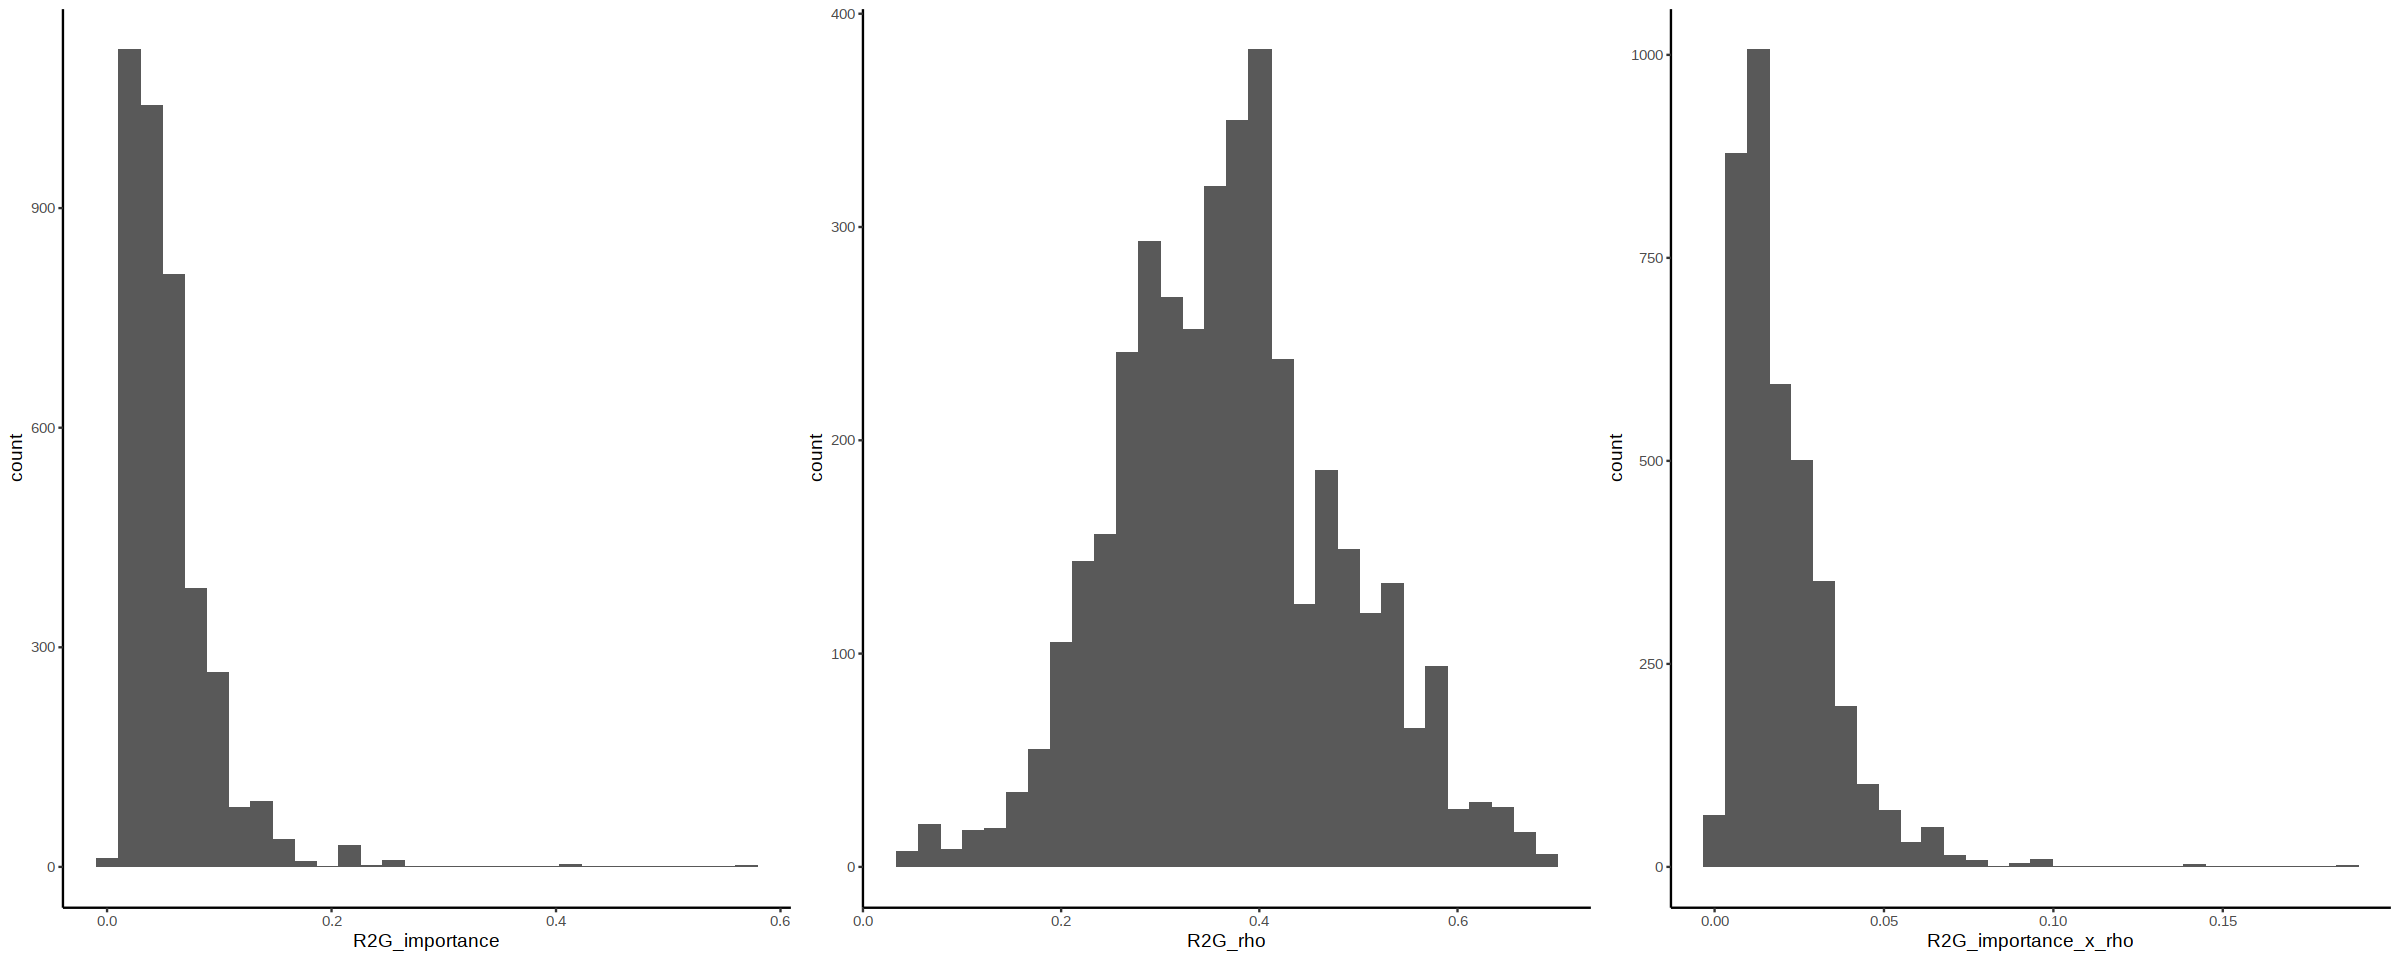

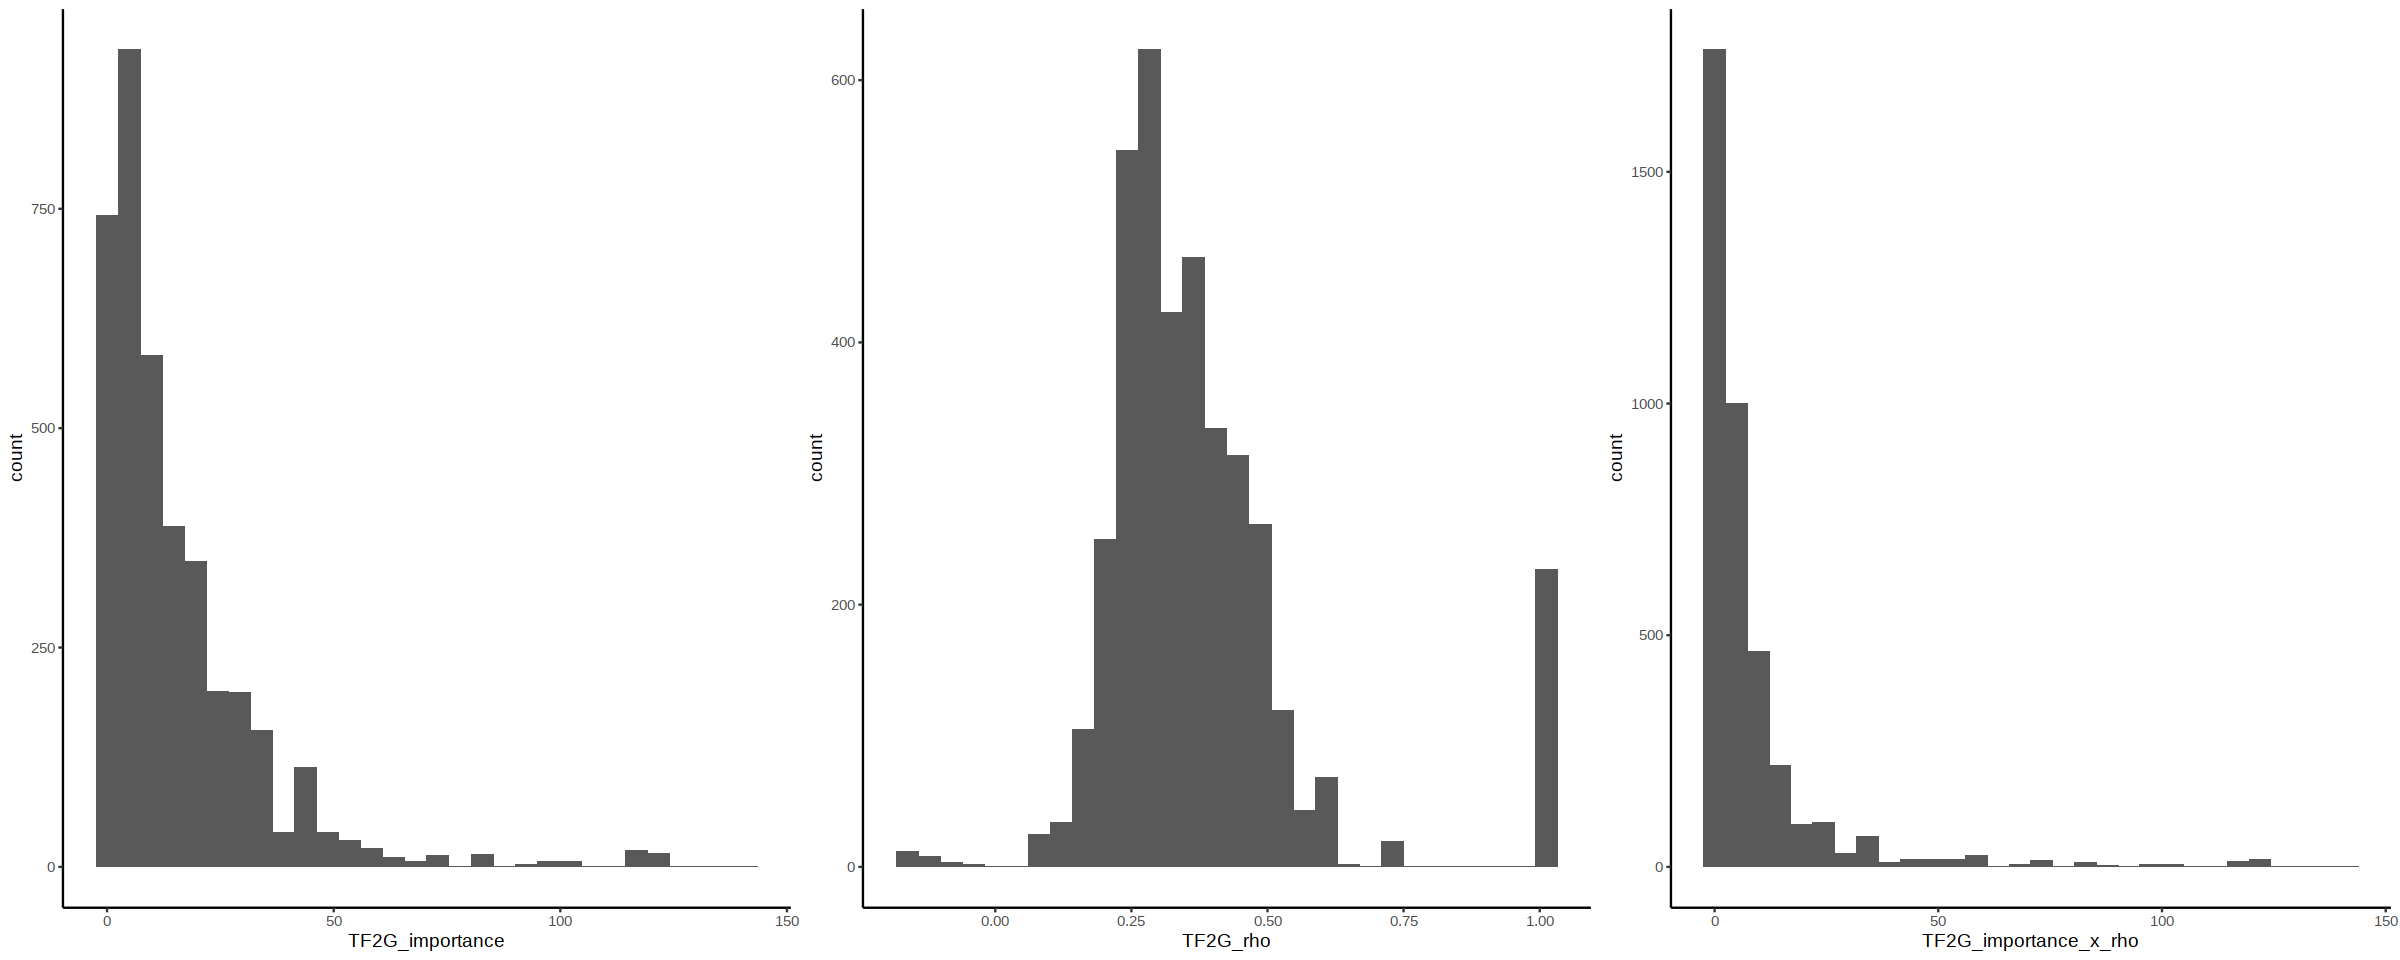

In [5]:
options(repr.plot.width=20, repr.plot.height=8)
ggarrange(
    ggplot(GRN_filt, aes(R2G_importance)) + geom_histogram() + theme_classic(),
    ggplot(GRN_filt, aes(R2G_rho)) + geom_histogram() + theme_classic(),
    ggplot(GRN_filt, aes(R2G_importance_x_rho)) + geom_histogram() + theme_classic(),
    ggplot(GRN_filt, aes(TF2G_importance)) + geom_histogram() + theme_classic(),
    ggplot(GRN_filt, aes(TF2G_rho)) + geom_histogram() + theme_classic(),
    ggplot(GRN_filt, aes(TF2G_importance_x_rho)) + geom_histogram() + theme_classic(),
    ncol=3
)

In [6]:
GRN_in = GRN_filt %>%
    .[R2G_rho> 0.25 & TF2G_rho>0] %>%
    .[,c('TF', 'Gene', 'TF2G_importance', 'TF2G_rho', 'TF2G_importance_x_rho')] %>% unique(by=c('TF', 'Gene'))

In [8]:
summary(GRN_in$TF2G_rho)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.06287 0.25988 0.33334 0.37650 0.43041 1.00000 

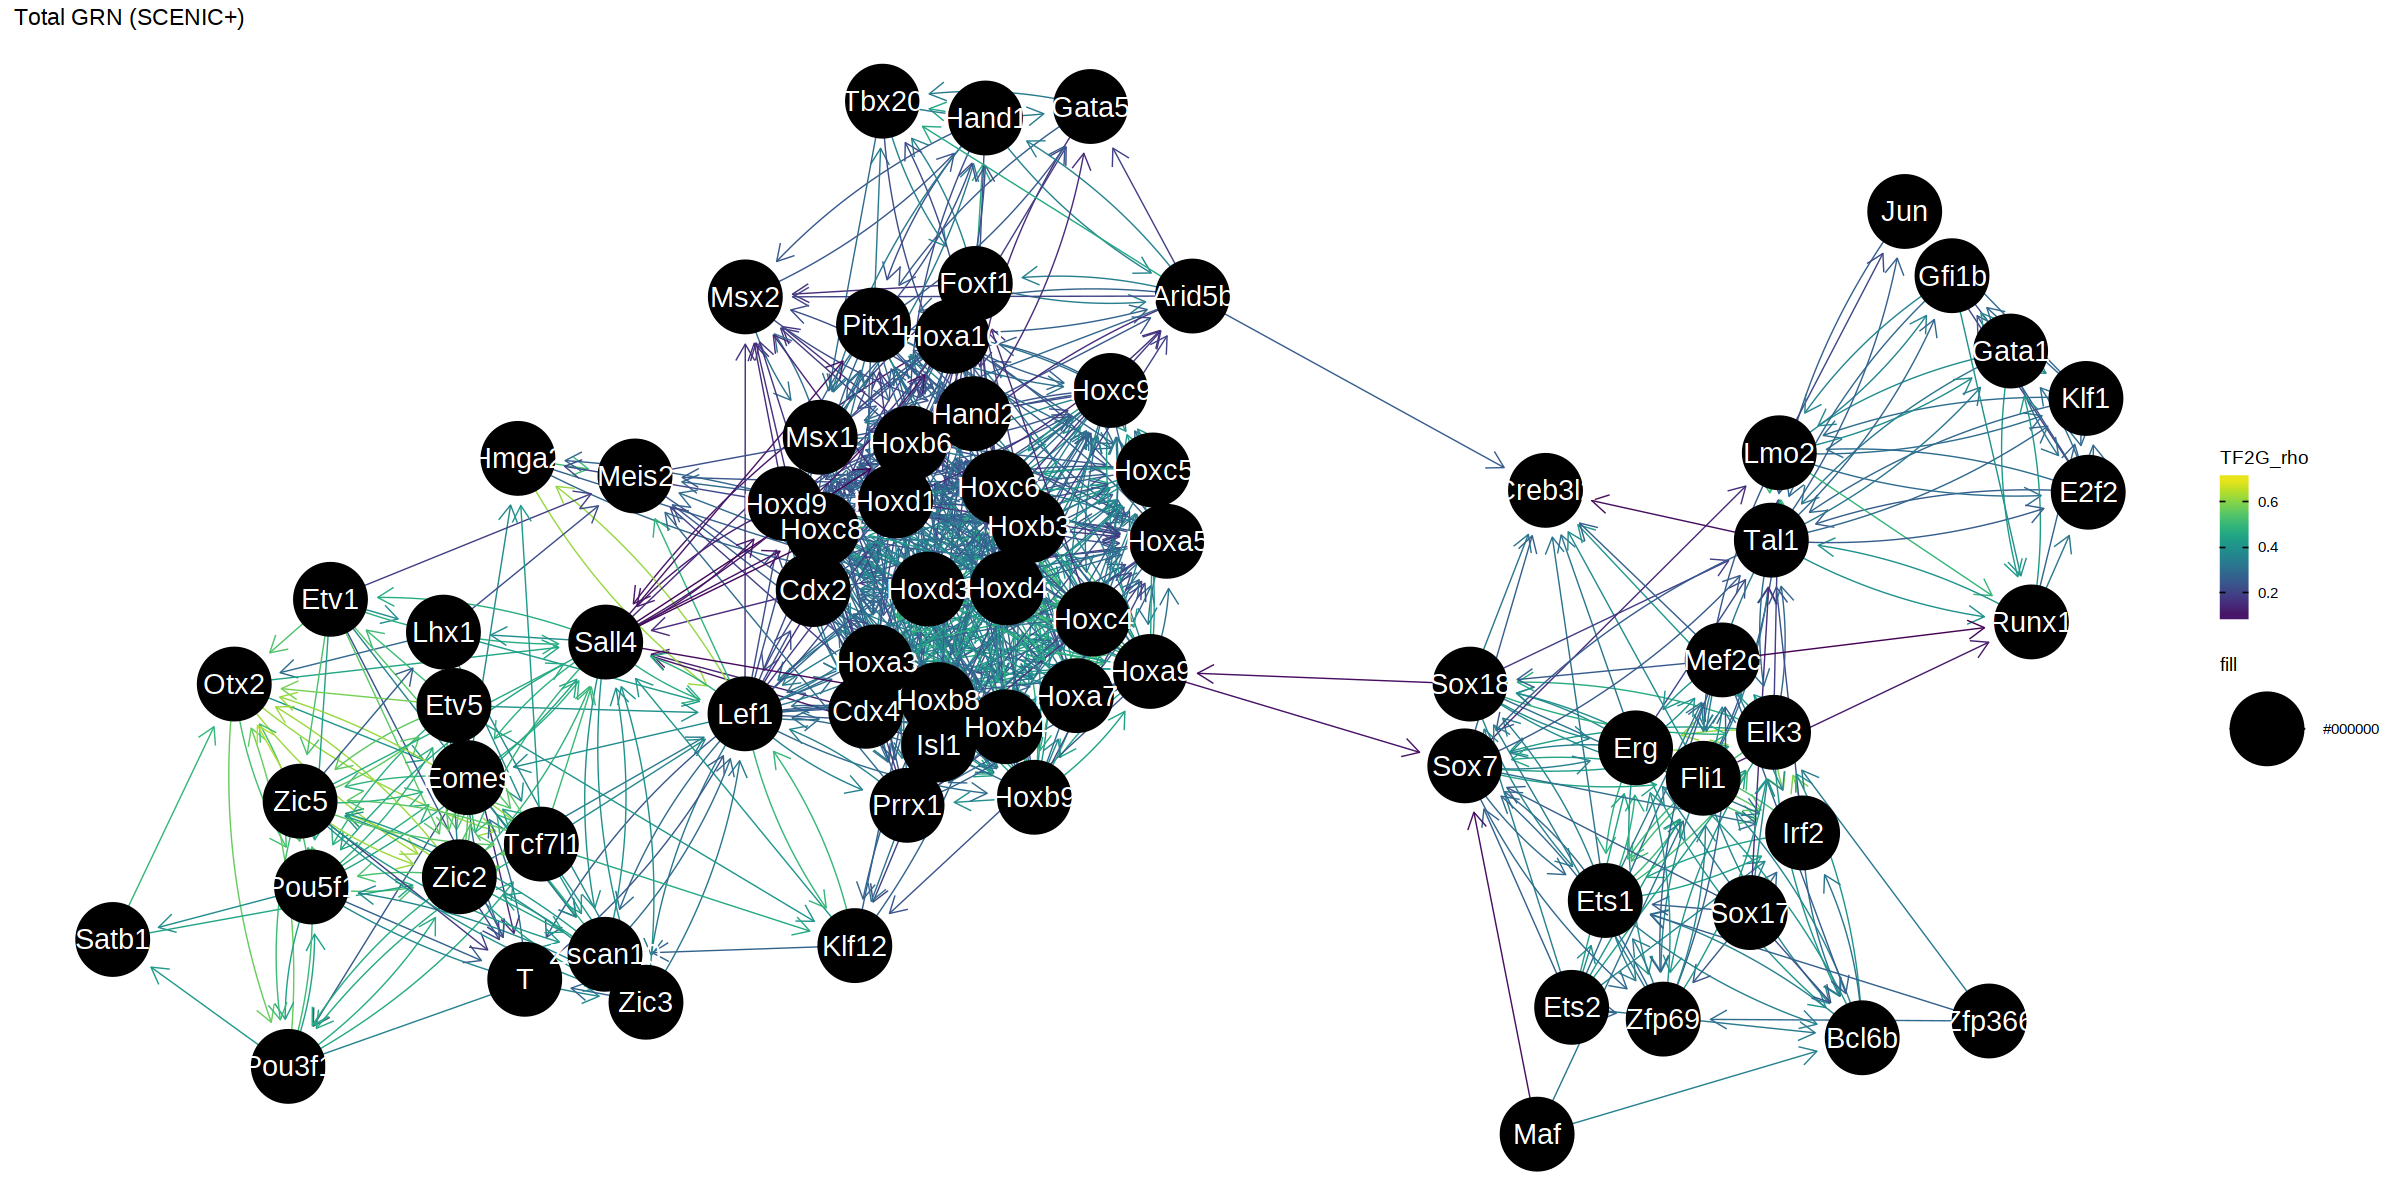

In [126]:
options(repr.plot.width=20, repr.plot.height=10)
igraph.tbl = tbl_graph(edges = GRN_in)
ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_fan(aes(edge_color=TF2G_rho), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
    scale_edge_colour_viridis() + 
    geom_node_point(aes( fill='#000000'), col='black', size=20) + 
    geom_node_text(aes(label=name), size=6, col='white') + 
    theme_graph() + 
    ggtitle('Total GRN (SCENIC+)') + theme(legend.position='none')

In [221]:
# individual TF
TFs = c('Tal1', 'Runx1', 'Gata1', 'Eomes', 'Fli1')

plots = list()
for(i in TFs){
GRN_in = GRN_filt %>%
.[R2G_rho> 0 & TF2G_rho>0.15] %>%
.[,c('TF', 'Gene', 'TF2G_importance', 'TF2G_rho', 'TF2G_importance_x_rho')] %>% unique(by=c('TF', 'Gene')) %>%
.[TF%in%i]
    
igraph.tbl = tbl_graph(edges = GRN_in)
plots[[i]] = ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_fan(aes(edge_color=TF2G_rho), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
    scale_edge_colour_viridis() + 
    geom_node_point(aes( fill='#000000'), col='black', size=20) + 
    geom_node_text(aes(label=name), size=6, col='white') + 
    theme_graph() + 
    ggtitle(i) + theme(legend.position='none')
}

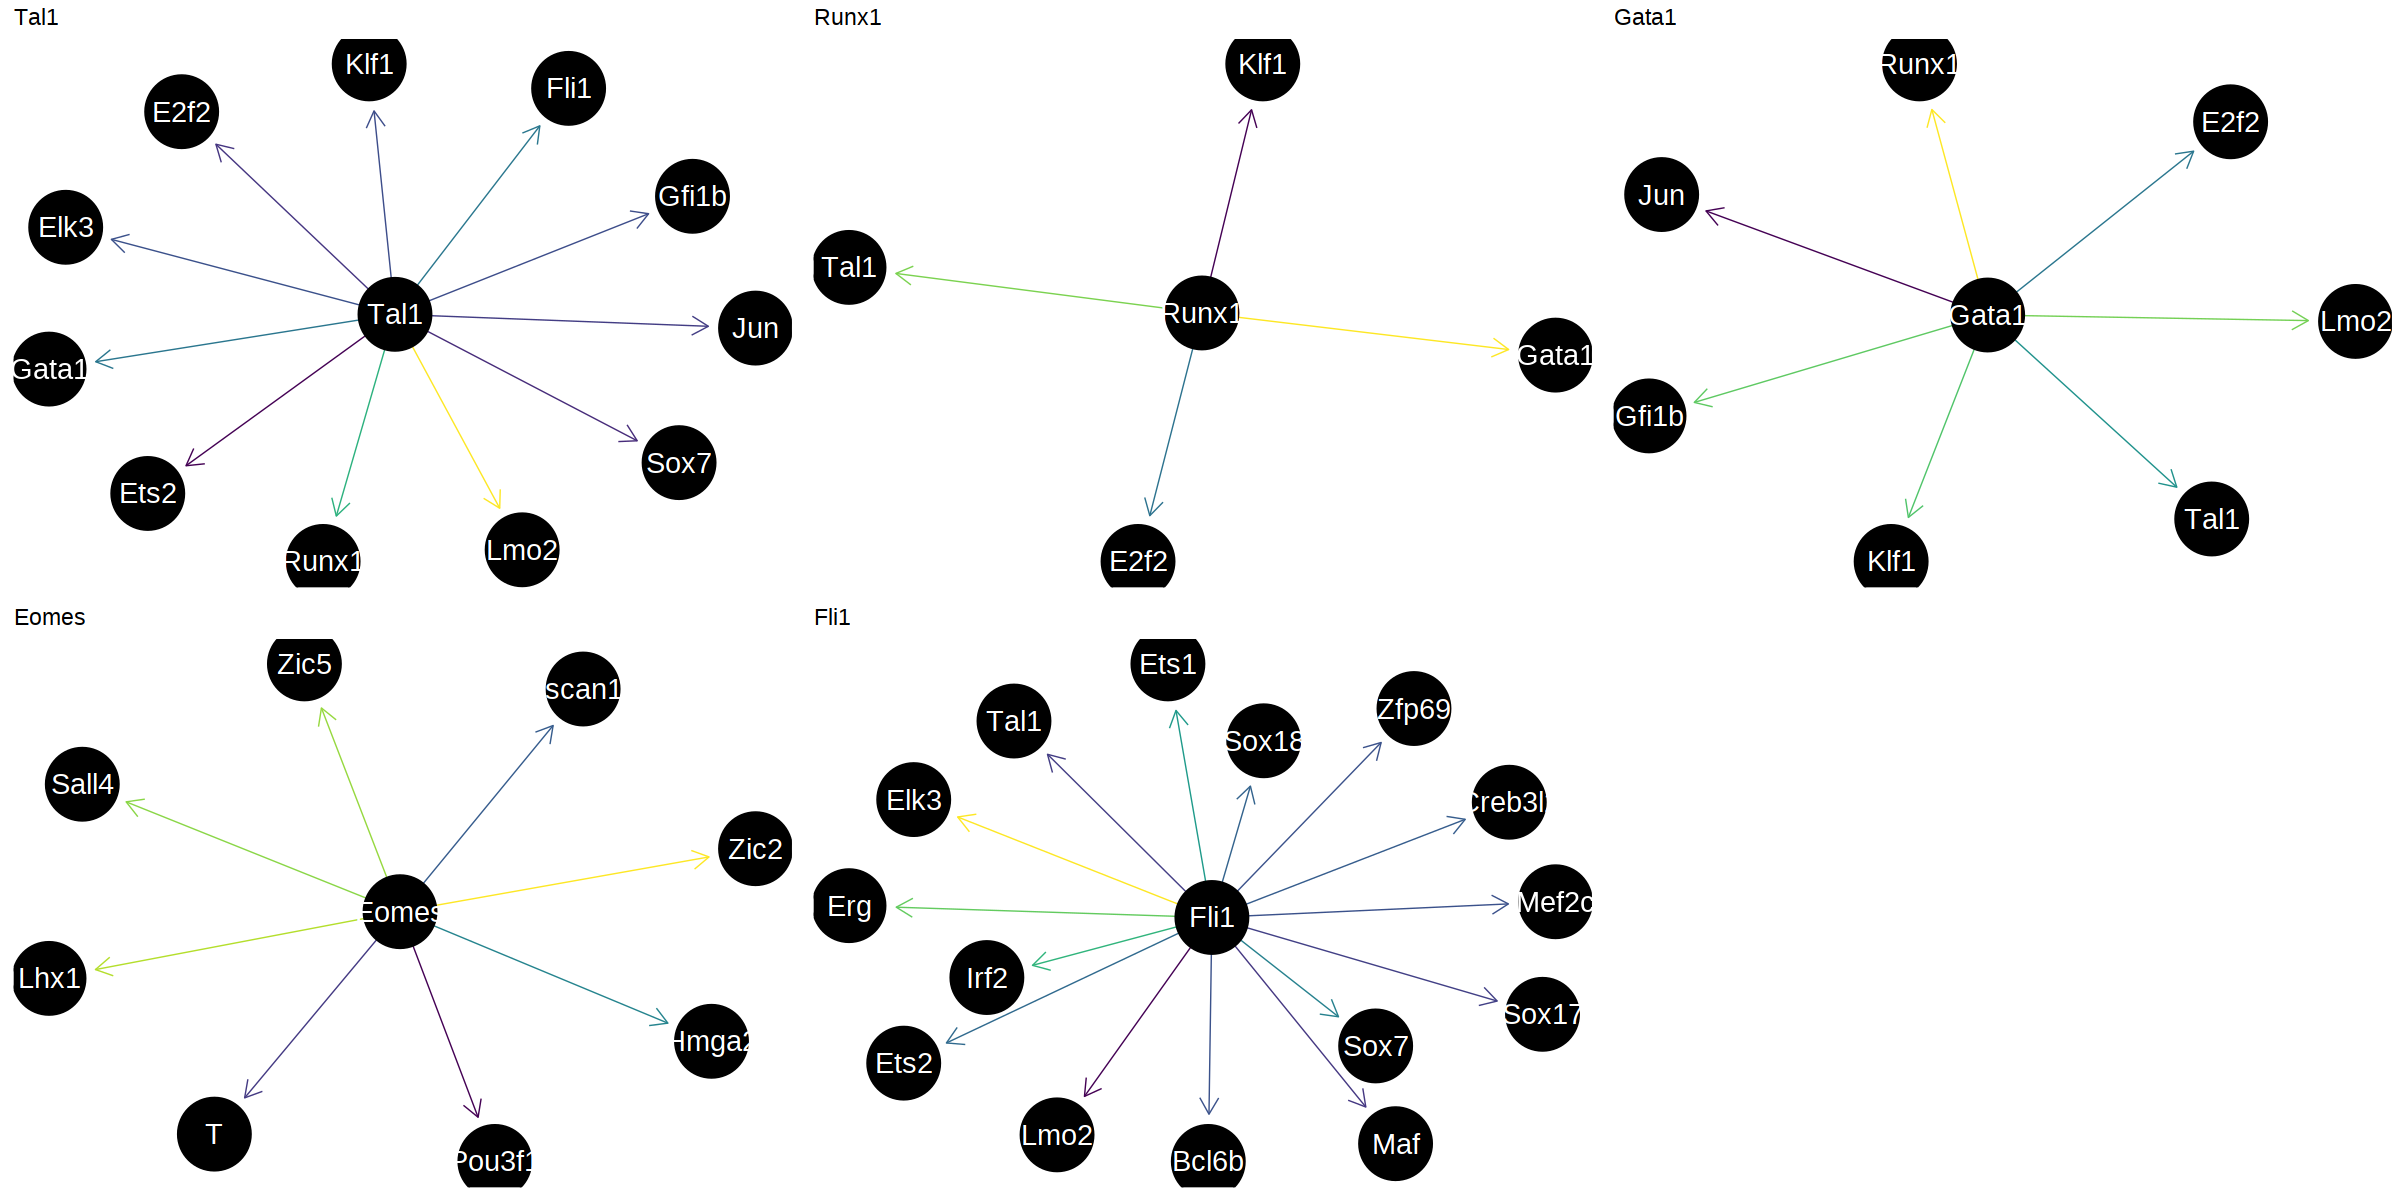

In [223]:
options(repr.plot.width=20, repr.plot.height=10)
ggarrange(plotlist=plots)

In [141]:
GRN_in = GRN_filt %>%
.[R2G_rho> 0.25 & TF2G_rho>0] %>%
.[,c('TF', 'Gene', 'TF2G_importance', 'TF2G_rho', 'TF2G_importance_x_rho')] %>% unique(by=c('TF', 'Gene')) %>%
.[TF%in%c('Fli1', 'Runx1')]
    
igraph.tbl = tbl_graph(edges = GRN_in)
plots[[i]] = ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_fan(aes(edge_color=TF2G_rho), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
    scale_edge_colour_viridis() + 
    geom_node_point(aes( fill='#000000'), col='black', size=20) + 
    geom_node_text(aes(label=name), size=6, col='white') + 
    theme_graph() + 
    ggtitle(i) + theme(legend.position='right')

# From full network

In [152]:
head(GRN_filt)

V1,Region_signature_name,Gene_signature_name,TF,is_extended,Region,Gene,R2G_importance,R2G_rho,R2G_importance_x_rho,R2G_importance_x_abs_rho,TF2G_importance,TF2G_regulation,TF2G_rho,TF2G_importance_x_abs_rho,TF2G_importance_x_rho,Consensus_name
<int>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>
43,Ahctf1_+_(168r),Ahctf1_+_(174g),Ahctf1,FALSE,chr9:60687660-60688260,Uaca,0.01617439,0.3506148,0.005670982,0.005670982,1.968841,1,0.1669848,0.3287666,0.3287666,Ahctf1_+_+
44,Ahctf1_+_(168r),Ahctf1_+_(174g),Ahctf1,FALSE,chr9:60940026-60940626,Uaca,0.06324093,0.4025139,0.025455354,0.025455354,1.968841,1,0.1669848,0.3287666,0.3287666,Ahctf1_+_+
181,Ahctf1_+_(168r),Ahctf1_+_(174g),Ahctf1,FALSE,chr4:6365340-6365940,Nsmaf,0.03987537,0.2612969,0.010419311,0.010419311,1.509019,1,0.2794076,0.4216315,0.4216315,Ahctf1_+_+
189,Ahctf1_+_(168r),Ahctf1_+_(174g),Ahctf1,FALSE,chrX:8074423-8075023,Gata1,0.02479061,0.4007687,0.009935300,0.009935300,1.560172,1,0.1660343,0.2590421,0.2590421,Ahctf1_+_+
0,Alx1_+_(12r),Alx1_+_(10g),Alx1,FALSE,chr8:57320723-57321323,Hand2,0.16088189,0.4073503,0.065535288,0.065535288,2.634727,1,0.1102895,0.2905827,0.2905827,Alx1_+_+
1,Alx1_+_(12r),Alx1_+_(10g),Alx1,FALSE,chr8:57318330-57318930,Hand2,0.10622642,0.3319793,0.035264970,0.035264970,2.634727,1,0.1102895,0.2905827,0.2905827,Alx1_+_+


In [29]:
nrow(GRN)
GRN_filt = GRN  %>%
    .[R2G_rho> 0.25 & TF2G_rho>0.25]

TFs <- intersect(GRN_filt[,.N,by="TF"][N>=3,TF], GRN_filt[,.N,by="Gene"][N>=3,Gene])
GRN_filt <- GRN_filt[TF%in%TFs & Gene%in%TFs] %>% 
    .[,c('TF', 'Gene', 'TF2G_importance', 'TF2G_rho', 'TF2G_importance_x_rho')] %>% unique(by=c('TF', 'Gene'))
nrow(GRN_filt)

[1] 152173

[1] 1329

In [13]:
expression = readRDS('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna/pseudobulk/celltype/SingleCellExperiment_TFs_pseudobulk.rds')

In [14]:
expression

class: SingleCellExperiment 
dim: 800 37 
metadata(2): agg_pars n_cells
assays(2): counts logcounts
rownames(800): FOXD1 IRF2 ... FOXM1 SMAD9
rowData names(0):
colnames(37): Allantois Anterior_Primitive_Streak ... Surface_ectoderm
  Visceral_endoderm
colData names(0):
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [17]:
max_expr = data.table(TF = rownames(expression), max_expr = rowMax(expression@assays@data$logcounts))

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



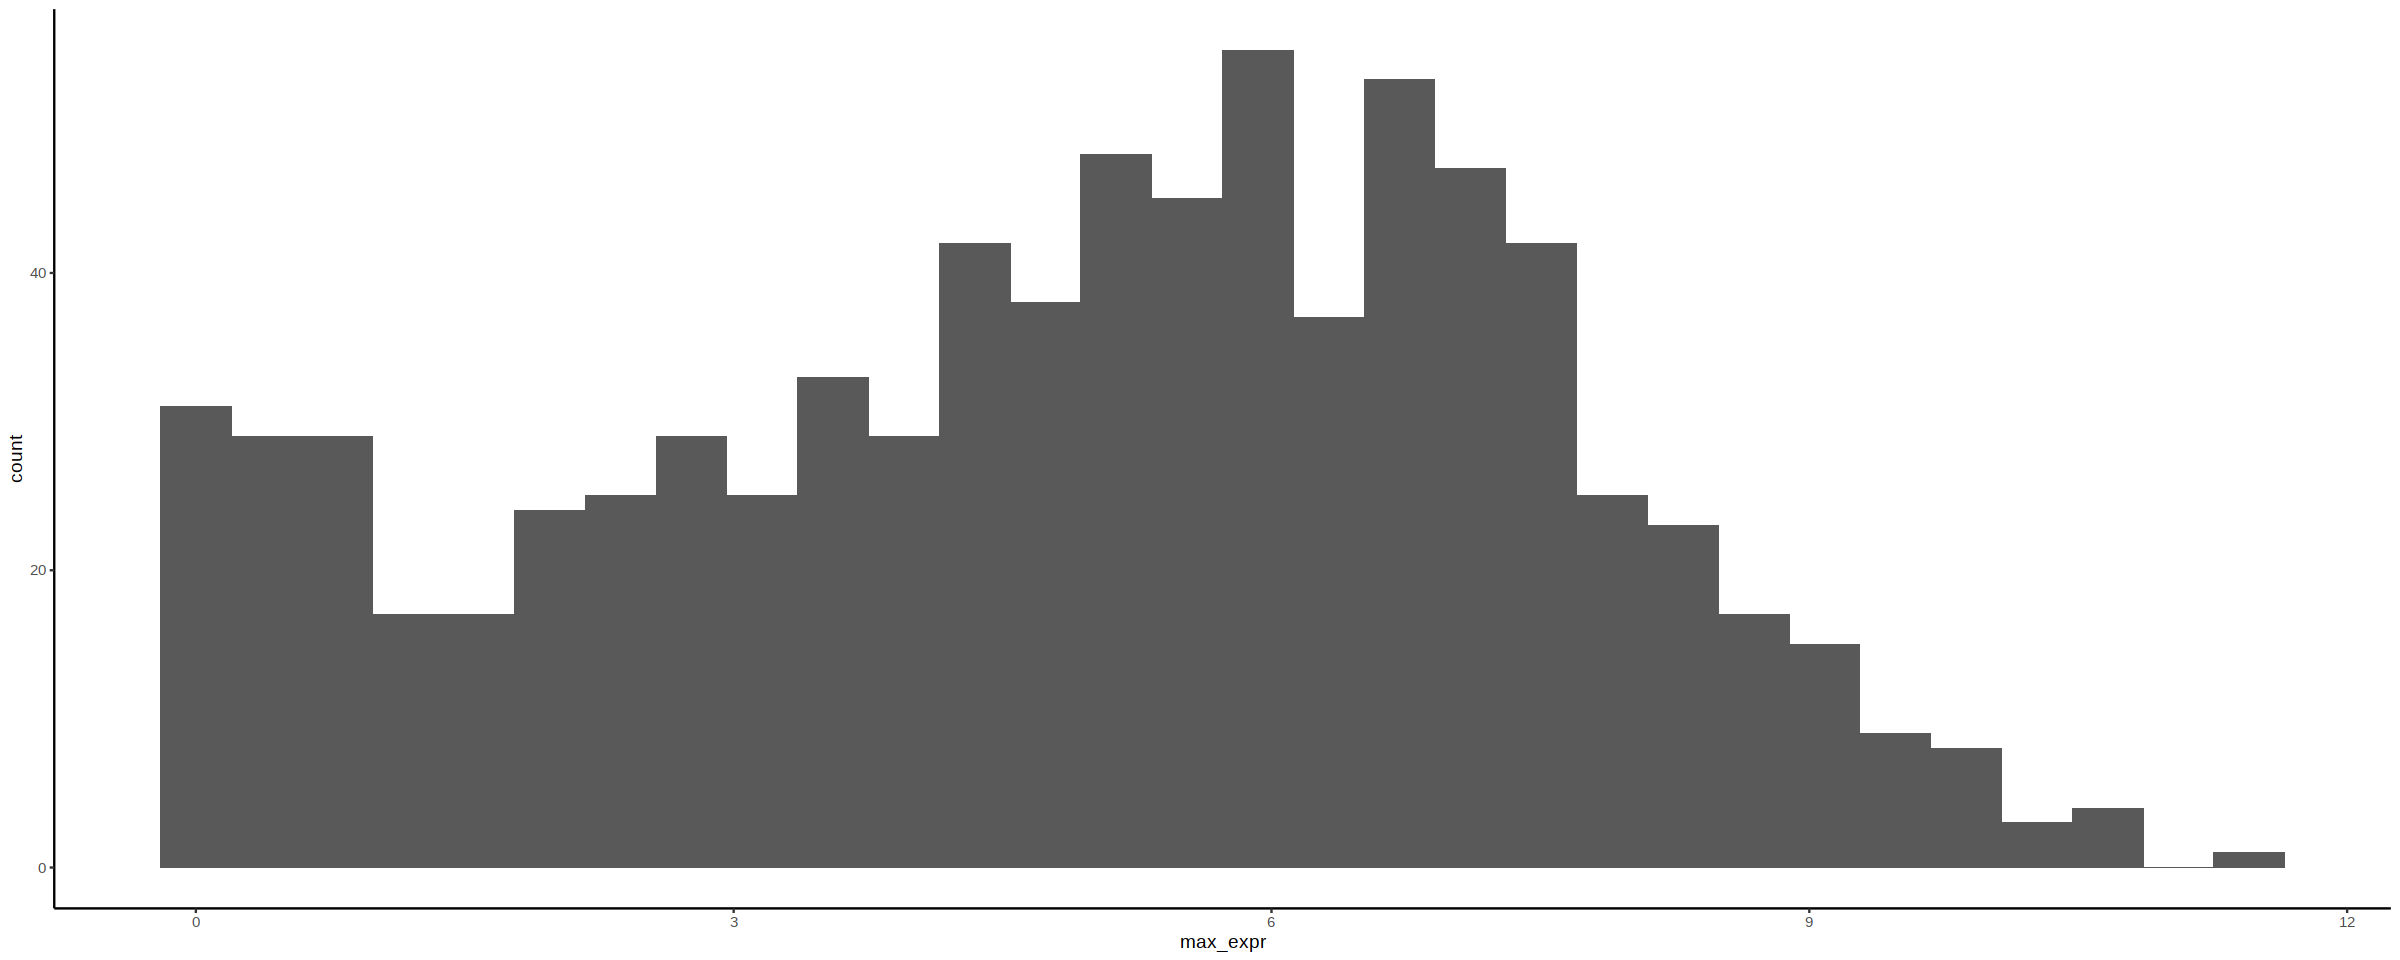

In [20]:
ggplot(max_expr, aes(max_expr)) + geom_histogram() + theme_classic()

In [32]:
TF_keep = stringr::str_to_title(max_expr[max_expr>3, TF])

In [34]:
GRN_filt = GRN_filt[TF%in%TF_keep & Gene%in%TF_keep]

In [35]:
fwrite(GRN_filt, file.path(io$basedir, 'GRN_test.csv'), row.names =FALSE)

In [44]:
celltypes.to.plot = c("Epiblast",
                        "Primitive_Streak" ,
                        "Nascent_mesoderm",
                        "ExE_mesoderm",
                        "Mixed_mesoderm",
                        "Allantois",
                        "Mesenchyme",
                        "Haematoendothelial_progenitors",
                        "Endothelium",
                        "Blood_progenitors_1",
                        "Blood_progenitors_2",
                        "Erythroid1",
                        "Erythroid2",
                        "Erythroid3")

In [134]:
marker_TFs_all.dt <- fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna/differential/metacells/celltype/TFs/marker_TFs_all.txt.gz') %>% 
  .[celltype%in%celltypes.to.plot] %>%
  .[,gene:=toupper(gene)] %>% 
  .[order(-score)] %>% unique(by='gene') %>%
#  .[score>0.75] %>%
  .[,TF:=stringr::str_to_title(gene)]

In [135]:
head(GRN_filt)
head(marker_TFs_all.dt)

TF,Gene,TF2G_importance,TF2G_rho,TF2G_importance_x_rho,name
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
Arid3b,Gata6,0.6300116,0.2949688,0.1858337,Arid3b
Arid3b,Pknox2,1.6608784,0.3126475,0.5192695,Arid3b
Arid3b,Meis2,1.7046561,0.3854537,0.6570661,Arid3b
Bach2,Bach2,26.6438651,1.0000000,26.6438651,Bach2
Bach2,Tead1,0.5187840,0.3539486,0.1836229,Bach2
Bach2,Klf12,0.9883104,0.3132600,0.3095981,Bach2


celltype,gene,score,TF
<chr>,<chr>,<dbl>,<chr>
Allantois,HOXA10,1,Hoxa10
Allantois,PITX1,1,Pitx1
Allantois,TBX4,1,Tbx4
Allantois,TWIST2,1,Twist2
Endothelium,BCL6B,1,Bcl6b
Endothelium,ERG,1,Erg


In [136]:
marker_TFs_all.dt[TF== 'T']

celltype,gene,score,TF
<chr>,<chr>,<dbl>,<chr>
Nascent_mesoderm,T,0.74,T


In [137]:
nodes.dt = data.table(TF= unique(c(GRN_filt$TF, GRN_filt$Gene))) %>% merge(marker_TFs_all.dt, by= 'TF', all.x=TRUE) 

In [139]:
igraph.tbl = tbl_graph(edges = GRN_filt, nodes=nodes.dt)

In [244]:
options(repr.plot.width=20, repr.plot.height=10)
p1 = ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_fan(aes(edge_color=TF2G_rho), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
    scale_edge_colour_continuous(low='white', high='darkgreen') + 
    geom_node_point(aes( col=celltype), size=20) + 
    scale_color_manual(values=opts$celltype.colors) +
    geom_node_text(aes(label=TF), size=5, col='gray99', fontface='bold') + 
    theme_graph() + 
    ggtitle('Total GRN (SCENIC+)') + 
    theme(legend.position='none',
         text=element_text(size=20))

In [248]:
args = list()
args$outdir = file.path(io$basedir, 'results/FYR_figures/')
dir.create(args$outdir, showWarnings = F)

In [252]:
pdf(sprintf('%s/scenic_GRN.pdf', args$outdir), width=20, height=10)
     print(p1)
dev.off()

png 
  2

In [225]:
minmax_expr = lapply(1:nrow(test), function(x){
    tmp = t(as.matrix(minmax.normalisation(test[x,])))
    rownames(tmp) = rownames(test)[x]
    return(tmp)
}) %>% do.call('rbind',.)
    

In [255]:
TF = 'Erythroid1'
plot_GRN_TF = function(celltype){
    TF_expr = data.table(TF = stringr::str_to_title(rownames(expression)), expression = minmax_expr[,celltype])

    nodes.dt = merge(nodes.dt[,1:4], TF_expr, by='TF')

    igraph.tbl = tbl_graph(edges = GRN_filt, nodes=nodes.dt)

    options(repr.plot.width=20, repr.plot.height=10)
    ggraph(igraph.tbl, 'stress') +
        # Edges
        geom_edge_fan(aes(edge_color=TF2G_rho), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
        scale_edge_colour_continuous(low='white', high='darkgreen') + 
        geom_node_point(aes(col=celltype, alpha=expression), size=20) + 
        scale_color_manual(values=opts$celltype.colors) +
        geom_node_text(aes(label=TF), size=5, col='gray99', fontface='bold') + 
        theme_graph() + 
        ggtitle(paste0('Total GRN (SCENIC+), alpha = ', celltype)) + 
        theme(legend.position='none',
             text=element_text(size=20))
}

In [257]:
for(celltype in celltypes.to.plot){
    pdf(sprintf('%s/scenic_GRN_%s.pdf', args$outdir, celltype), width=20, height=10)
         print(plot_GRN_TF(celltype))
    dev.off()
}

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



$`1`

$`2`

attr(,"class")
[1] "list"      "ggarrange"

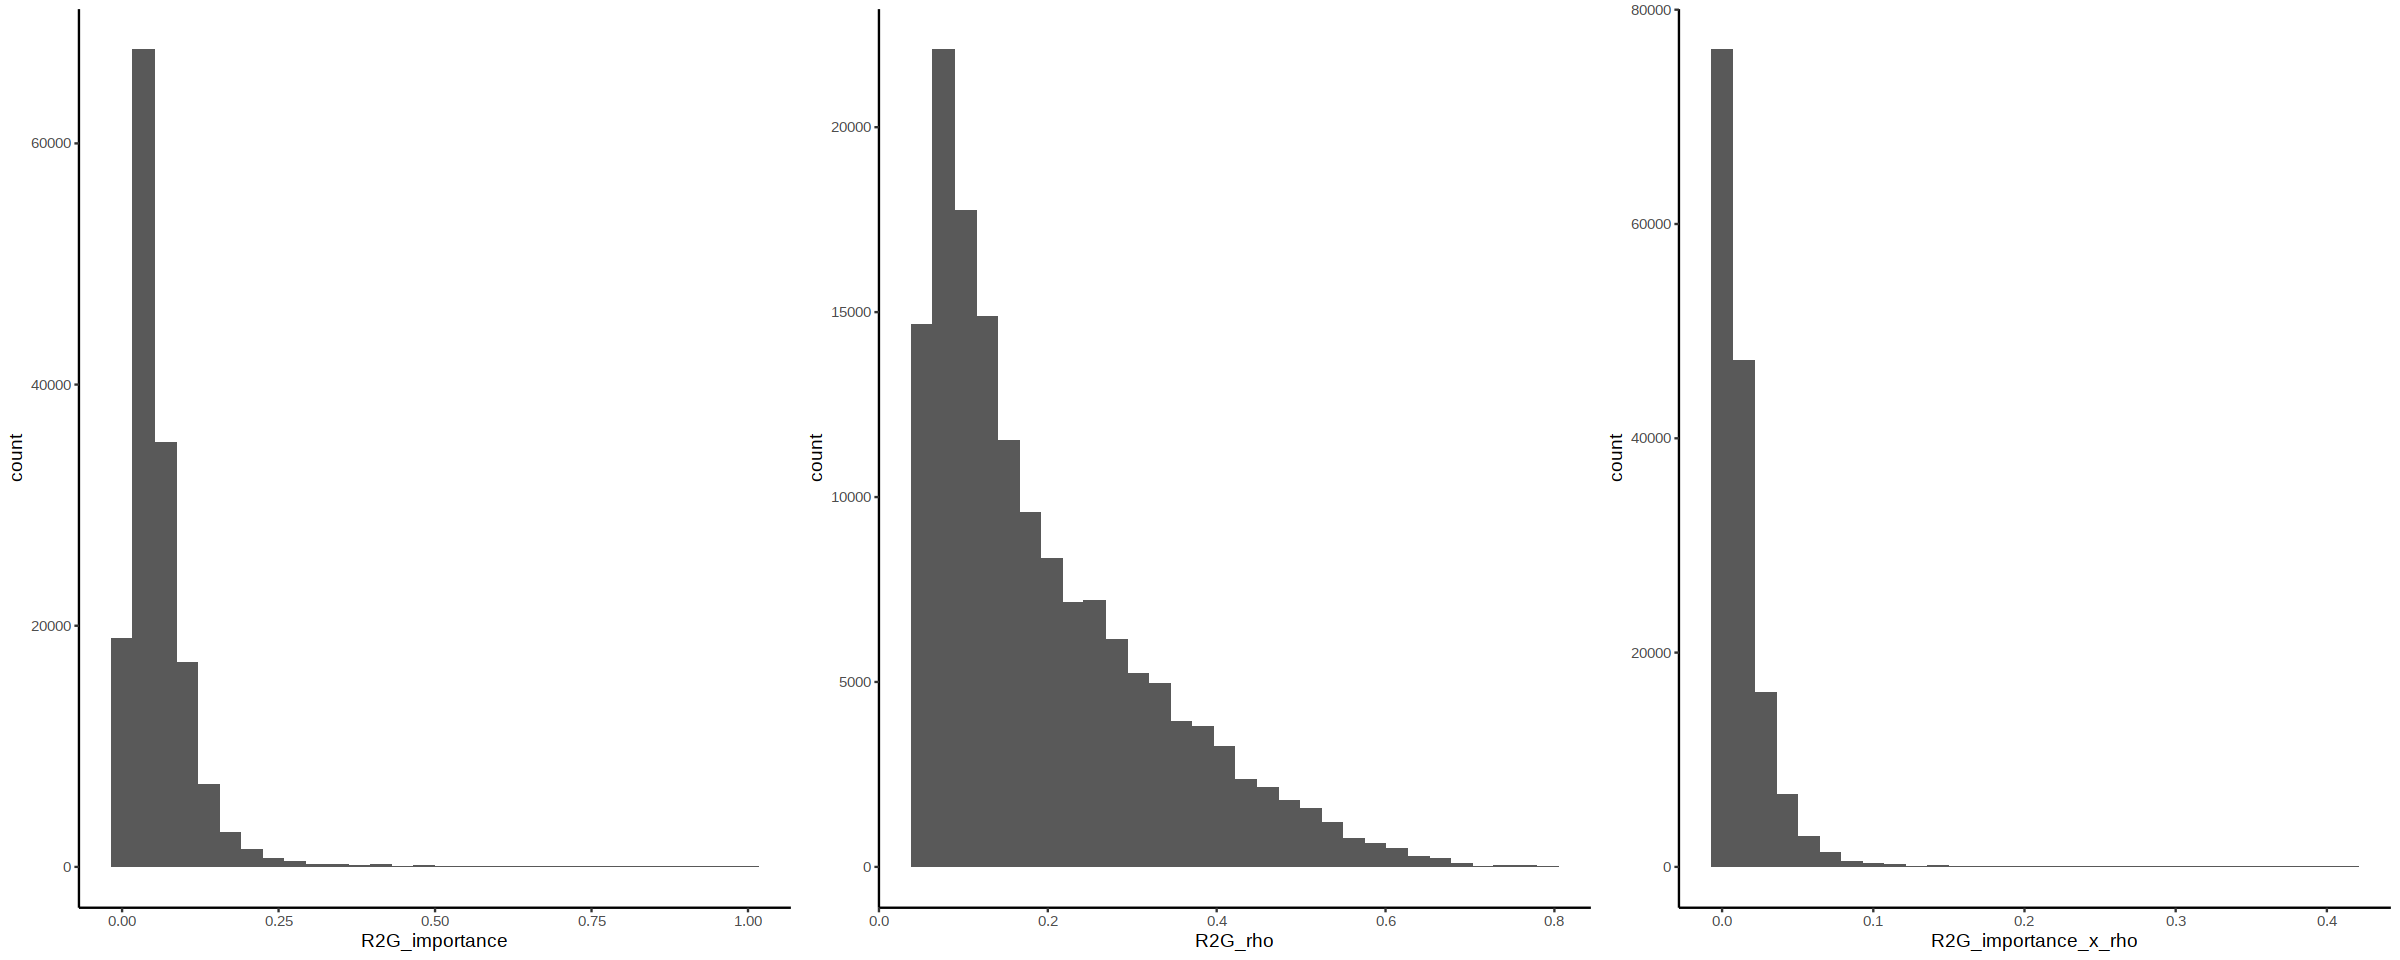

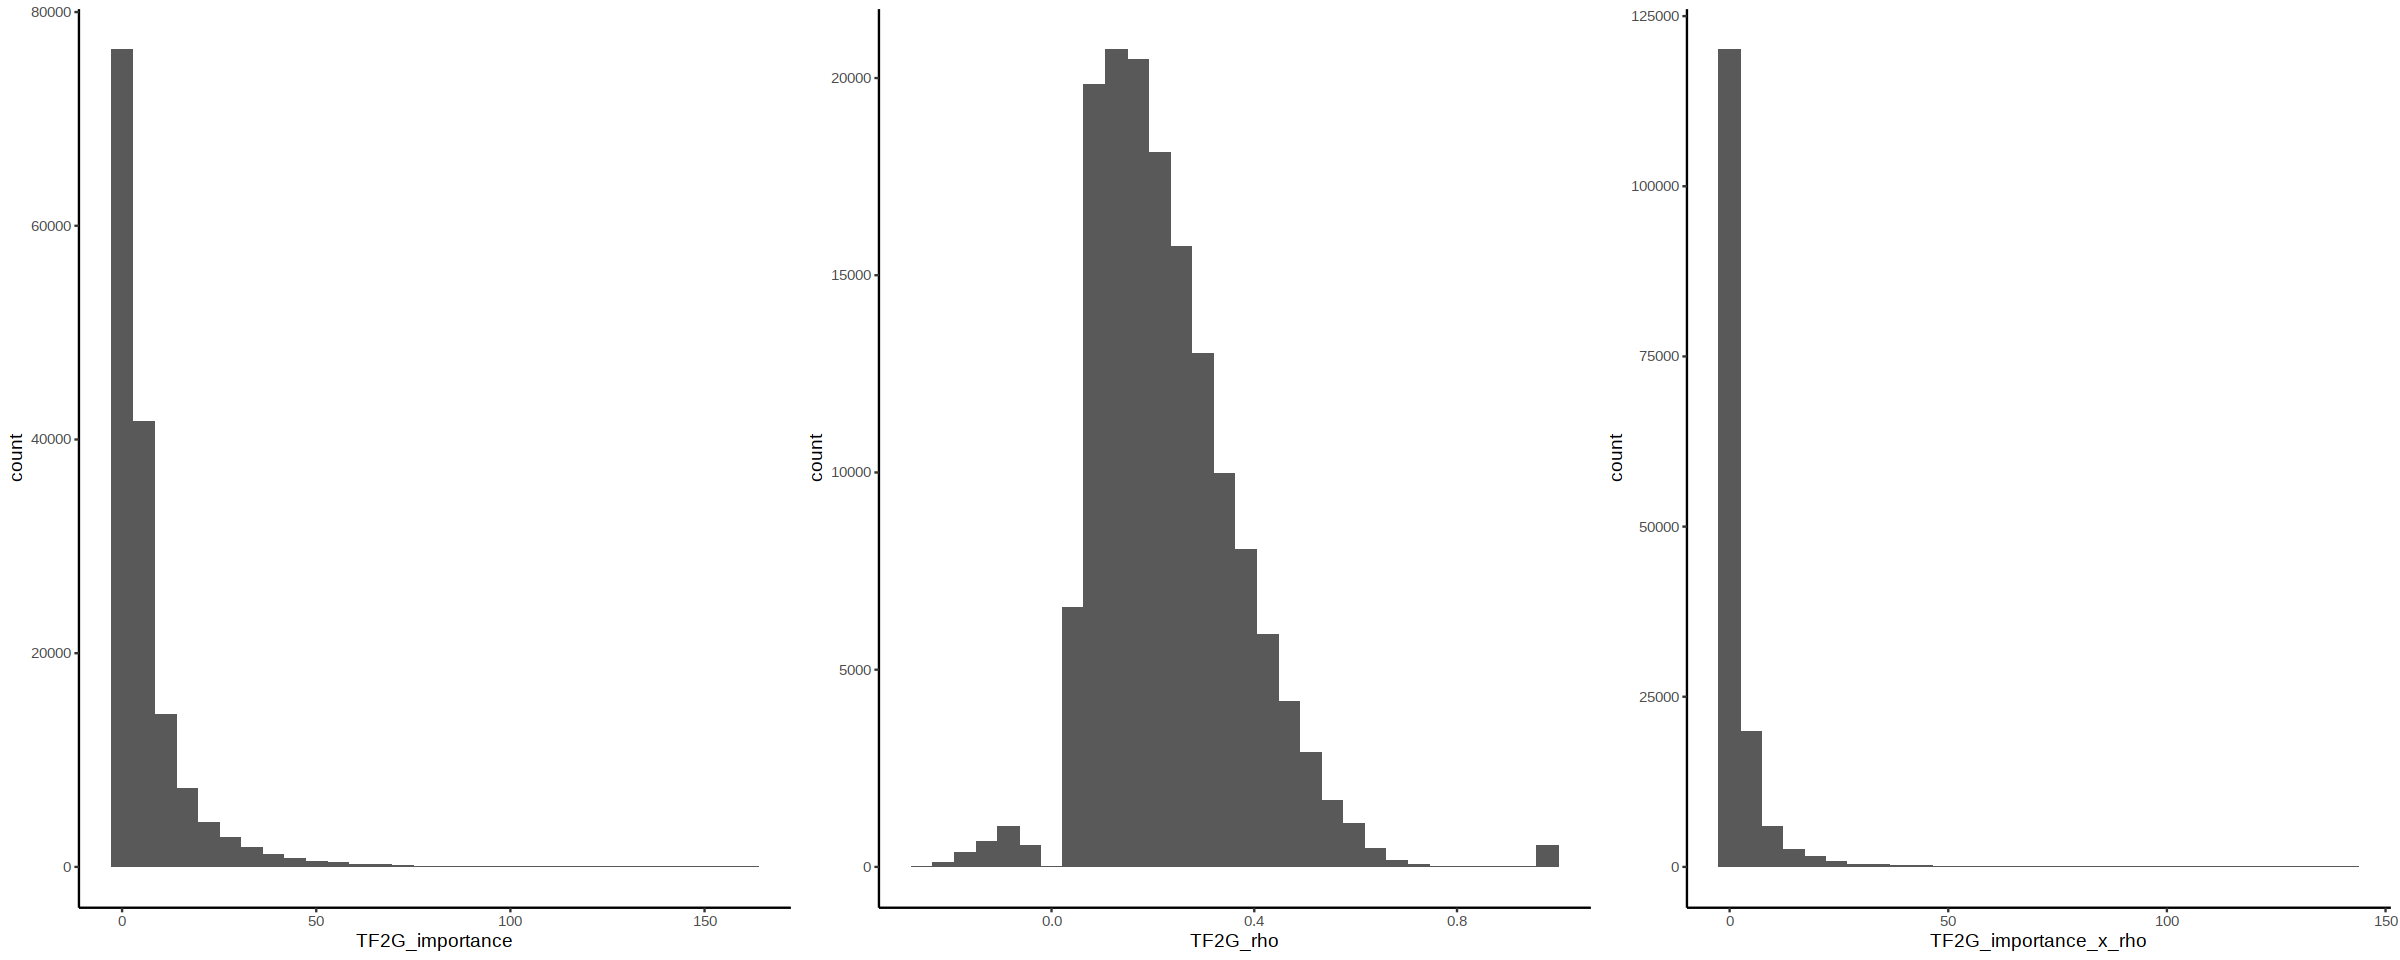

In [165]:
options(repr.plot.width=20, repr.plot.height=8)
ggarrange(
    ggplot(GRN, aes(R2G_importance)) + geom_histogram() + theme_classic(),
    ggplot(GRN, aes(R2G_rho)) + geom_histogram() + theme_classic(),
    ggplot(GRN, aes(R2G_importance_x_rho)) + geom_histogram() + theme_classic(),
    ggplot(GRN, aes(TF2G_importance)) + geom_histogram() + theme_classic(),
    ggplot(GRN, aes(TF2G_rho)) + geom_histogram() + theme_classic(),
    ggplot(GRN, aes(TF2G_importance_x_rho)) + geom_histogram() + theme_classic(),
    ncol=3
)

In [180]:
nrow(GRN)
GRN_filt = GRN  %>%
    .[R2G_rho> 0.5 & TF2G_rho>0.25]

TFs <- c('Gata1', 'Tal1', 'Runx1', 'Gfi1b', 'Lmo2', 'E2f2', 'Klf1', 'Erg', 'Fli1', 'Jun')
GRN_filt <- GRN_filt[TF%in%TFs] %>% 
    .[,c('TF', 'Gene', 'TF2G_importance', 'TF2G_rho', 'TF2G_importance_x_rho')] %>% unique(by=c('TF', 'Gene'))
nrow(GRN_filt)

[1] 152173

[1] 282

In [181]:
nodes.dt = data.table(node=unique(c(GRN_filt$TF, GRN_filt$Gene))) %>%
    .[,type:=ifelse(node %in% GRN_filt$TF, 'TF', 'Target')]

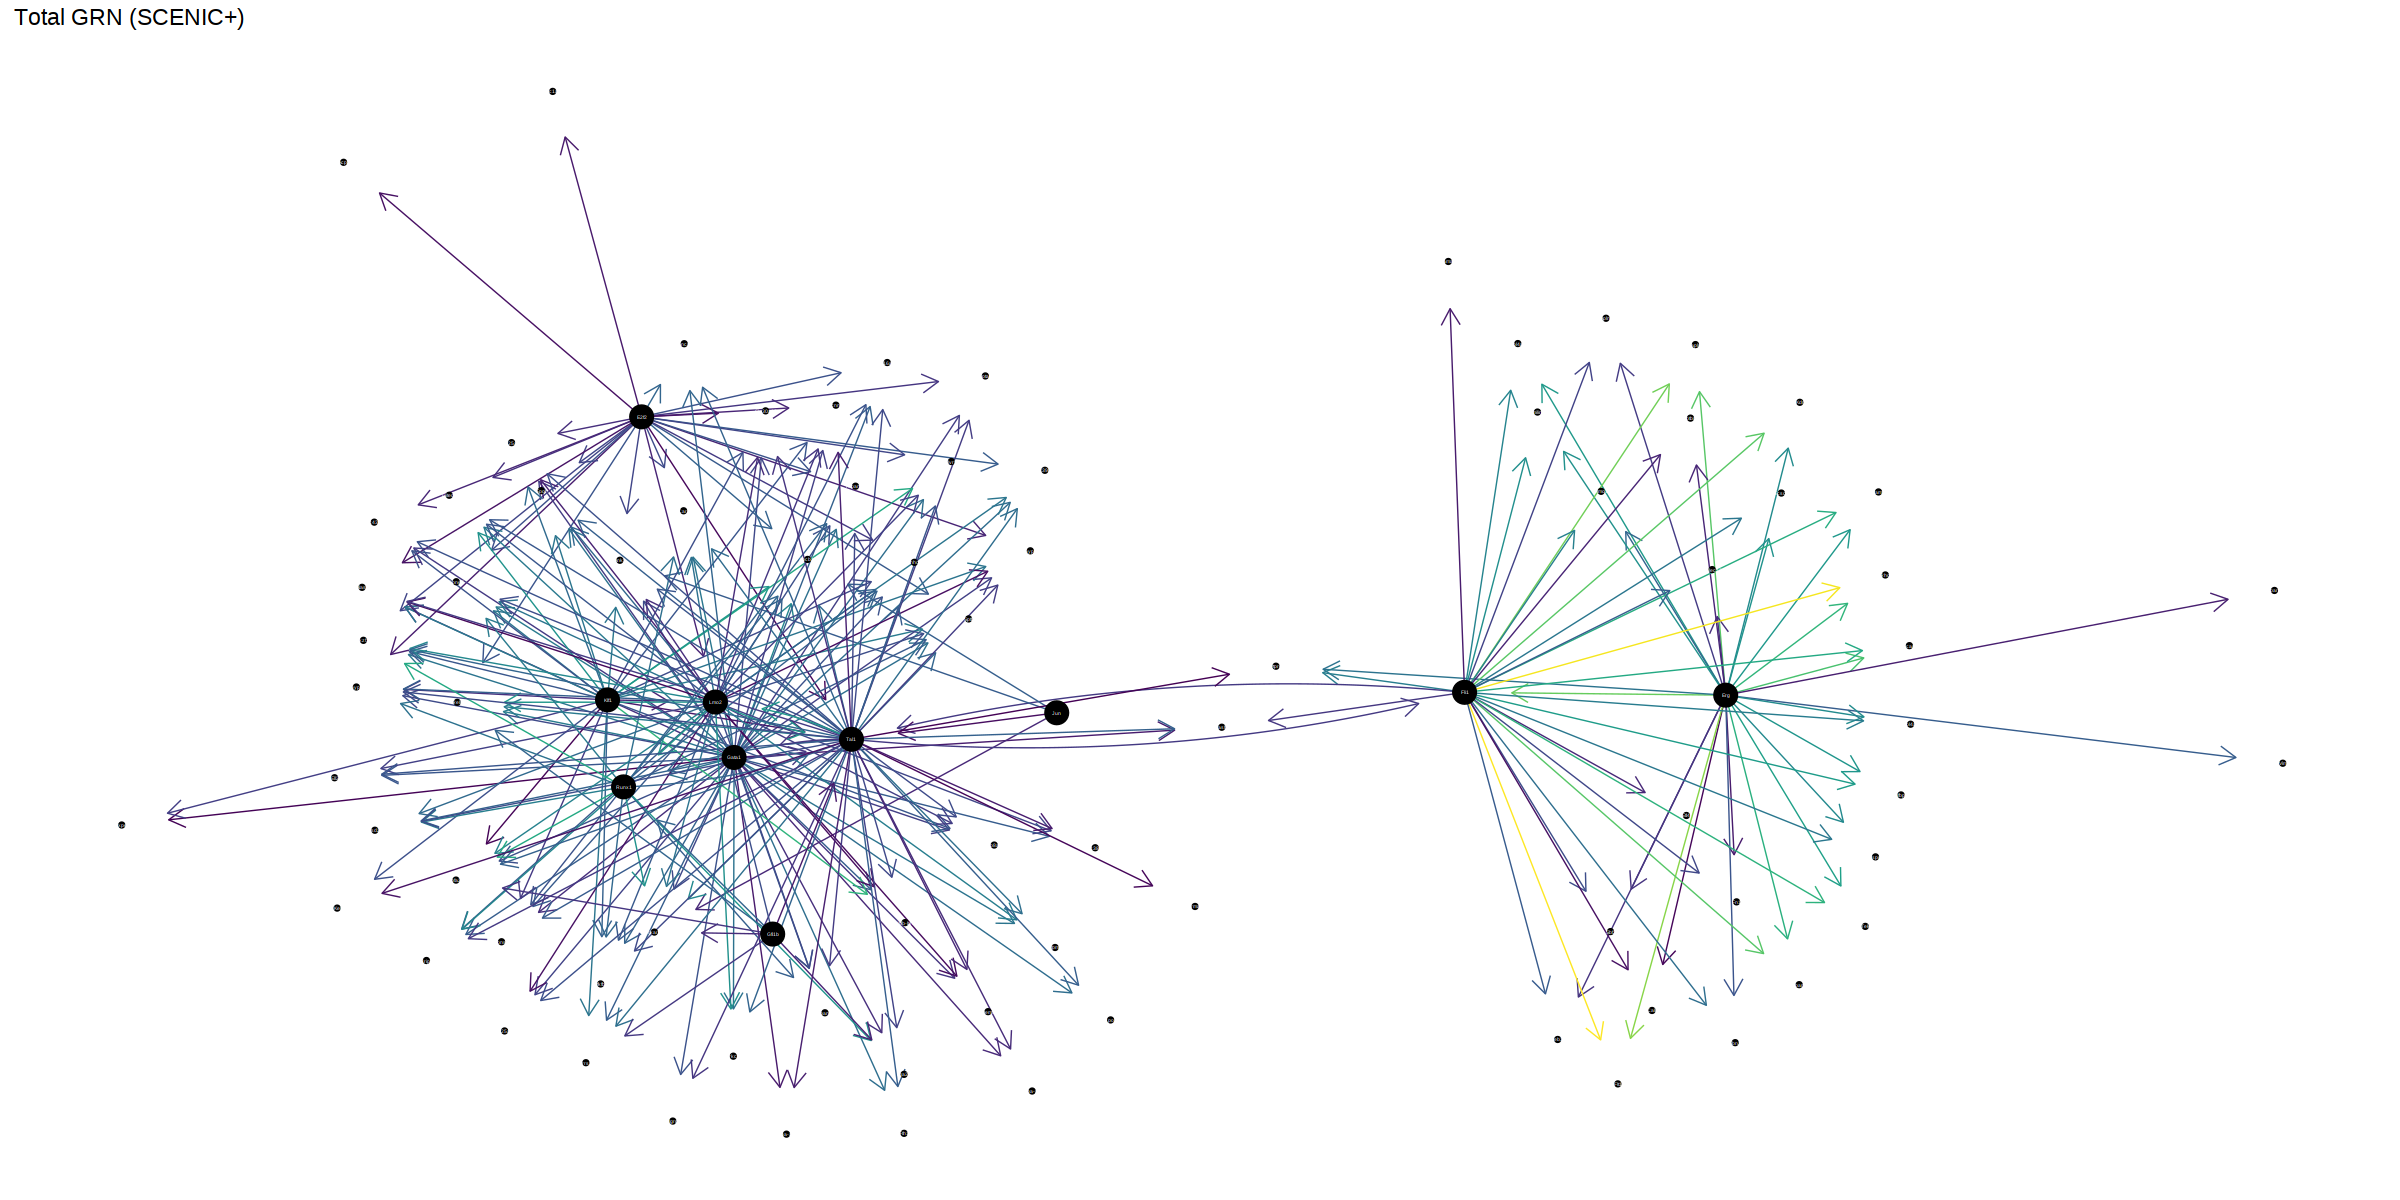

In [187]:
options(repr.plot.width=20, repr.plot.height=10)
igraph.tbl = tbl_graph(edges = GRN_filt, nodes=nodes.dt)
ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_fan(aes(edge_color=TF2G_rho), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
    scale_edge_colour_viridis() + 
    geom_node_point(aes(size=ifelse(type=='TF', 5, 1), fill='#000000'), col='black') + 
    geom_node_text(aes(label=node, size=ifelse(type=='TF', 5, 1)), size=1, col='white') + 
    theme_graph() + 
    ggtitle('Total GRN (SCENIC+)') + theme(legend.position='none')